# 🎨 Data Designer Tutorial: Providing Images as Context for Vision-Based Data Generation

#### 📚 What you'll learn

This notebook demonstrates how to provide images as context to generate text descriptions using vision-language models.

- ✨ **Visual Document Processing**: Converting images to chat-ready format for model consumption
- 🔍 **Vision-Language Generation**: Using vision models to generate detailed summaries from images

If this is your first time using Data Designer, we recommend starting with the [first notebook](https://nvidia-nemo.github.io/DataDesigner/latest/notebooks/1-the-basics/) in this tutorial series.


### 📦 Import Data Designer

- `data_designer.config` provides access to the configuration API.

- `DataDesigner` is the main interface for data generation.


In [1]:
# Standard library imports
import base64
import io
import uuid

# Third-party imports
import pandas as pd
import rich
from datasets import load_dataset
from IPython.display import display
from rich.panel import Panel

# Data Designer imports
import data_designer.config as dd
from data_designer.interface import DataDesigner

### ⚙️ Initialize the Data Designer interface

- `DataDesigner` is the main object responsible for managing the data generation process.

- When initialized without arguments, the [default model providers](https://nvidia-nemo.github.io/DataDesigner/latest/concepts/models/default-model-settings/) are used.


In [2]:
data_designer = DataDesigner()

### 🏗️ Initialize the Data Designer Config Builder

- The Data Designer config defines the dataset schema and generation process.

- The config builder provides an intuitive interface for building this configuration.

- When initialized without arguments, the [default model configurations](https://nvidia-nemo.github.io/DataDesigner/latest/concepts/models/default-model-settings/) are used.


In [3]:
config_builder = dd.DataDesignerConfigBuilder()

### 🌱 Seed Dataset Creation

In this section, we'll prepare our visual documents as a seed dataset for summarization:

- **Loading Visual Documents**: We use a small pets image dataset containing labeled images
- **Image Processing**: Convert images to base64 format for vision model consumption
- **Metadata Extraction**: Preserve relevant image information (label, etc.)

The seed dataset will be used to generate detailed text descriptions of each image.

In [4]:
# Dataset processing configuration
IMG_COUNT = 512  # Number of images to process
BASE64_IMAGE_HEIGHT = 512  # Standardized height for model input

# Load the pets dataset (train split, ~23 MB total)
img_dataset_cfg = {"path": "rokmr/pets", "split": "train"}

In [5]:
def resize_image(image, height: int):
    """
    Resize image while maintaining aspect ratio.

    Args:
        image: PIL Image object
        height: Target height in pixels

    Returns:
        Resized PIL Image object
    """
    original_width, original_height = image.size
    width = int(original_width * (height / original_height))
    return image.resize((width, height))


def convert_image_to_chat_format(record, height: int) -> dict:
    """
    Convert PIL image to base64 format for chat template usage.

    Args:
        record: Dataset record containing image and metadata
        height: Target height for image resizing

    Returns:
        Updated record with base64_image and uuid fields
    """
    image = resize_image(record["image"], height)

    img_buffer = io.BytesIO()
    image.save(img_buffer, format="PNG")
    byte_data = img_buffer.getvalue()
    base64_encoded_data = base64.b64encode(byte_data)
    base64_string = base64_encoded_data.decode("utf-8")

    return record | {"base64_image": base64_string, "uuid": str(uuid.uuid4())}

In [6]:
# Load and process the image dataset
print("📥 Loading and processing images...")

img_dataset = load_dataset(**img_dataset_cfg).map(
    convert_image_to_chat_format, fn_kwargs={"height": BASE64_IMAGE_HEIGHT}
)
img_dataset = pd.DataFrame(img_dataset[:IMG_COUNT])

print(f"✅ Loaded {len(img_dataset)} images with columns: {list(img_dataset.columns)}")

📥 Loading and processing images...


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train.zip:   0%|          | 0.00/20.4M [00:00<?, ?B/s]

data/test.zip:   0%|          | 0.00/3.29M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/900 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

✅ Loaded 512 images with columns: ['image', 'label', 'base64_image', 'uuid']


In [7]:
img_dataset.head()

,image,label,base64_image,uuid
0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,0,iVBORw0KGgoAAAANSUhEUgAAAeQAAAIACAIAAADc8YinAA...,3270323e-d574-4842-8837-1e2aba960b8a
1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,0,iVBORw0KGgoAAAANSUhEUgAAAiQAAAIACAIAAAA9rOAHAA...,f06d4b12-239b-40a6-bd6e-30acf6fe9f14
2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,0,iVBORw0KGgoAAAANSUhEUgAAAqoAAAIACAIAAADFYNm1AA...,72dd60ec-42cd-42e7-8840-00bf50cd61ea
3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,0,iVBORw0KGgoAAAANSUhEUgAAAwAAAAIACAIAAAC6lJxtAA...,f9c4a858-58cc-4971-a951-fffa506597a7
4,<PIL.PngImagePlugin.PngImageFile image mode=RG...,0,iVBORw0KGgoAAAANSUhEUgAAAqoAAAIACAIAAADFYNm1AA...,a2274a13-99e8-4f39-bf2d-b08936448d8c


In [8]:
# Add the seed dataset containing our processed images
df_seed = pd.DataFrame(img_dataset)[["uuid", "label", "base64_image"]]
config_builder.with_seed_dataset(dd.DataFrameSeedSource(df=df_seed))

DataDesignerConfigBuilder(
    seed_dataset: df seed
)

In [9]:
# Add a column to generate detailed image descriptions
config_builder.add_column(
    dd.LLMTextColumnConfig(
        name="description",
        model_alias="nvidia-vision",
        prompt=(
            "Provide a detailed description of the content in this image in Markdown format. "
            "Describe the main subject, background, colors, and any notable details."
        ),
        multi_modal_context=[dd.ImageContext(column_name="base64_image")],
    )
)

data_designer.validate(config_builder)

[12:14:56] [INFO] ✅ Validation passed


### 🔁 Iteration is key – preview the dataset!

1. Use the `preview` method to generate a sample of records quickly.

2. Inspect the results for quality and format issues.

3. Adjust column configurations, prompts, or parameters as needed.

4. Re-run the preview until satisfied.


In [10]:
preview = data_designer.preview(config_builder, num_records=2)

[12:14:56] [INFO] 🔭 Preview generation in progress


[12:14:56] [INFO] ✅ Validation passed


[12:14:56] [INFO] ⛓️ Sorting column configs into a Directed Acyclic Graph


[12:14:56] [INFO] 🩺 Running health checks for models...


[12:14:56] [INFO]   |-- 👀 Checking 'nvidia/nemotron-nano-12b-v2-vl' in provider named 'nvidia' for model alias 'nvidia-vision'...


...

[12:15:00] [INFO]   |-- tokens: input=606, output=311, total=917, tps=319


[12:15:00] [INFO]   |-- requests: success=2, failed=0, total=2, rpm=41


[12:15:00] [INFO] 📐 Measuring dataset column statistics:


[12:15:00] [INFO]   |-- 📝 column: 'description'


[12:15:00] [INFO] 🎉 Preview complete!


In [11]:
# Run this cell multiple times to cycle through the 2 preview records.
preview.display_sample_record()

                                                 Seed Columns                                                 
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Name         ┃ Value                                                                                       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ uuid         │ 3270323e-d574-4842-8837-1e2aba960b8a                                                        │
├──────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ label        │ 0                                                                                           │
├──────────────┼─────────────────────────────────────────────────────────────────────────────────────────────┤
│ base64_image │ iVBORw0KGgoAAAANSUhEUgAAAeQAAAIACAIAAADc8YinAAEAAElEQVR4nOy9V5ckuZEmamZwEREpSna1YAv28JLDHT… │
└──────────────┴─────────────────────────────────────────────────────────────────────────────────────────────┘
                                                                                                              
                                                                                                              
                                              Generated Columns                                               
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Name        ┃ Value                                                                                        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ description │ This close-up portrait captures the face of a black-and-white cat.                           │
│             │                                                                                              │
│             │ -   **Main Subject:** The primary subject of the image is a cat. It is a close-up shot,      │
│             │ emphasizing the cat's facial features.                                                       │
│             │ -   **Background:** The background is blurred, drawing focus to the cat. It appears to be an │
│             │ indoor setting, possibly a room with light-colored walls.                                    │
│             │ -   **Colors:** The cat has a striking black-and-white coat. Its eyes are a vivid green, and │
│             │ the nose is a pinkish hue. The fur's contrasting colors are sharp, making the cat stand out  │
│             │ against the softer, blurred background.                                                      │
│             │ -   **Notable Details:** The cat's eyes are wide open and expressive, and its whiskers are   │
│             │ long and prominent. The cat's ears are pointed upwards, indicating alertness or curiosity.   │
│             │ The overall expression of the cat appears calm and attentive.                                │
└─────────────┴──────────────────────────────────────────────────────────────────────────────────────────────┘
                                                                                                              
                                                  [index: 0]

In [12]:
# The preview dataset is available as a pandas DataFrame.
preview.dataset

,uuid,label,base64_image,description
0,3270323e-d574-4842-8837-1e2aba960b8a,0,iVBORw0KGgoAAAANSUhEUgAAAeQAAAIACAIAAADc8YinAA...,This close-up portrait captures the face of a ...
1,f06d4b12-239b-40a6-bd6e-30acf6fe9f14,0,iVBORw0KGgoAAAANSUhEUgAAAiQAAAIACAIAAAA9rOAHAA...,1. **Main Subject**: The main subject of the i...


### 📊 Analyze the generated data

- Data Designer automatically generates a basic statistical analysis of the generated data.

- This analysis is available via the `analysis` property of generation result objects.


In [13]:
# Print the analysis as a table.
preview.analysis.to_report()

──────────────────────────────────────── 🎨 Data Designer Dataset Profile ─────────────────────────────────────────

                                                                                                                   
                                                 Dataset Overview                                                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ number of records               ┃ number of columns               ┃ percent complete records                    ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 2                               │ 1                               │ 100.0%                                      │
└─────────────────────────────────┴─────────────────────────────────┴─────────────────────────────────────────────┘
                                                                                                                   
                                                                                                                   
                                                📝 LLM-Text Columns                                                
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                  ┃               ┃                              ┃       prompt tokens ┃       completion tokens ┃
┃ column name      ┃     data type ┃         number unique values ┃          per record ┃              per record ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ description      │        string │                   2 (100.0%) │        29.0 +/- 0.0 │          152.5 +/- 36.1 │
└──────────────────┴───────────────┴──────────────────────────────┴─────────────────────┴─────────────────────────┘
                                                                                                                   
                                                                                                                   
╭────────────────────────────────────────────────── Table Notes ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  1. All token statistics are based on a sample of max(1000, len(dataset)) records.                              │
│  2. Tokens are calculated using tiktoken's cl100k_base tokenizer.                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
                                                                                                                   
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

### 🔎 Visual Inspection

Let's compare the original image with the generated description to validate quality:


📄 Original Image:


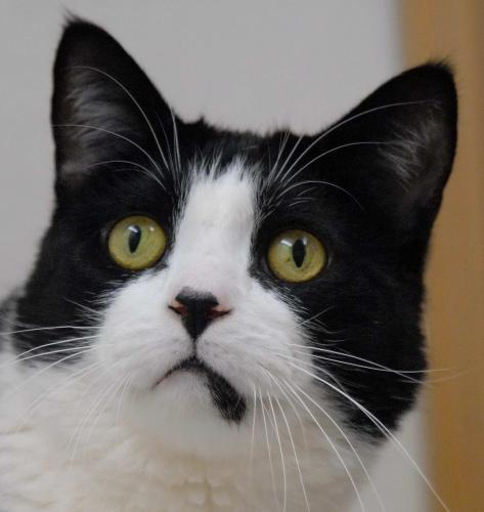


📝 Generated Description:


╭─ Image Description ─────────────────────────────────────────────────────────────────────────────────────────────╮
│ This close-up portrait captures the face of a black-and-white cat.                                              │
│                                                                                                                 │
│ -   **Main Subject:** The primary subject of the image is a cat. It is a close-up shot, emphasizing the cat's   │
│ facial features.                                                                                                │
│ -   **Background:** The background is blurred, drawing focus to the cat. It appears to be an indoor setting,    │
│ possibly a room with light-colored walls.                                                                       │
│ -   **Colors:** The cat has a striking black-and-white coat. Its eyes are a vivid green, and the nose is a      │
│ pinkish hue. The fur's contrasting colors are sharp, making the cat stand out against the softer, blurred       │
│ background.                                                                                                     │
│ -   **Notable Details:** The cat's eyes are wide open and expressive, and its whiskers are long and prominent.  │
│ The cat's ears are pointed upwards, indicating alertness or curiosity. The overall expression of the cat        │
│ appears calm and attentive.                                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [14]:
# Compare original image with generated description
index = 0  # Change this to view different examples

# Merge preview data with original images for comparison
comparison_dataset = preview.dataset.merge(pd.DataFrame(img_dataset)[["uuid", "image"]], how="left", on="uuid")

# Extract the record for display
record = comparison_dataset.iloc[index]

print("📄 Original Image:")
display(resize_image(record.image, BASE64_IMAGE_HEIGHT))

print("\n📝 Generated Description:")
rich.print(Panel(record.description, title="Image Description", title_align="left"))

### 🆙 Scale up!

- Happy with your preview data?

- Use the `create` method to submit larger Data Designer generation jobs.


In [15]:
results = data_designer.create(config_builder, num_records=10, dataset_name="tutorial-4")

[12:15:00] [INFO] 🎨 Creating Data Designer dataset


[12:15:00] [INFO] ✅ Validation passed


[12:15:00] [INFO] ⛓️ Sorting column configs into a Directed Acyclic Graph


[12:15:00] [INFO] 🩺 Running health checks for models...


[12:15:00] [INFO]   |-- 👀 Checking 'nvidia/nemotron-nano-12b-v2-vl' in provider named 'nvidia' for model alias 'nvidia-vision'...


...

[12:15:11] [INFO]   |-- model: nvidia/nemotron-nano-12b-v2-vl


[12:15:11] [INFO]   |-- tokens: input=22998, output=1997, total=24995, tps=2410


[12:15:11] [INFO]   |-- requests: success=10, failed=0, total=10, rpm=57


[12:15:11] [INFO] 📐 Measuring dataset column statistics:


[12:15:11] [INFO]   |-- 📝 column: 'description'


In [16]:
# Load the generated dataset as a pandas DataFrame.
dataset = results.load_dataset()

dataset.head()

,uuid,label,base64_image,description
0,3270323e-d574-4842-8837-1e2aba960b8a,0,iVBORw0KGgoAAAANSUhEUgAAAeQAAAIACAIAAADc8YinAA...,This image is a close-up portrait of a black a...
1,f06d4b12-239b-40a6-bd6e-30acf6fe9f14,0,iVBORw0KGgoAAAANSUhEUgAAAiQAAAIACAIAAAA9rOAHAA...,# Cat Image Description This is an image of a...
2,72dd60ec-42cd-42e7-8840-00bf50cd61ea,0,iVBORw0KGgoAAAANSUhEUgAAAqoAAAIACAIAAADFYNm1AA...,```markdown # Image Description The image fea...
3,f9c4a858-58cc-4971-a951-fffa506597a7,0,iVBORw0KGgoAAAANSUhEUgAAAwAAAAIACAIAAAC6lJxtAA...,![Cat in Green Container](https://images.unspl...
4,a2274a13-99e8-4f39-bf2d-b08936448d8c,0,iVBORw0KGgoAAAANSUhEUgAAAqoAAAIACAIAAADFYNm1AA...,```| Characteristic | Detail | | --- | --- | |...


In [17]:
# Load the analysis results into memory.
analysis = results.load_analysis()

analysis.to_report()

──────────────────────────────────────── 🎨 Data Designer Dataset Profile ─────────────────────────────────────────

                                                                                                                   
                                                 Dataset Overview                                                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ number of records               ┃ number of columns               ┃ percent complete records                    ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 10                              │ 1                               │ 100.0%                                      │
└─────────────────────────────────┴─────────────────────────────────┴─────────────────────────────────────────────┘
                                                                                                                   
                                                                                                                   
                                                📝 LLM-Text Columns                                                
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                  ┃               ┃                              ┃       prompt tokens ┃       completion tokens ┃
┃ column name      ┃     data type ┃         number unique values ┃          per record ┃              per record ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ description      │        string │                  10 (100.0%) │        29.0 +/- 0.0 │         178.5 +/- 108.0 │
└──────────────────┴───────────────┴──────────────────────────────┴─────────────────────┴─────────────────────────┘
                                                                                                                   
                                                                                                                   
╭────────────────────────────────────────────────── Table Notes ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  1. All token statistics are based on a sample of max(1000, len(dataset)) records.                              │
│  2. Tokens are calculated using tiktoken's cl100k_base tokenizer.                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
                                                                                                                   
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

## ⏭️ Next Steps

Now that you've learned how to use visual context for image summarization in Data Designer, explore more:

- Experiment with different vision models for specific image types
- Try different prompt variations to generate specialized descriptions (e.g., technical details, key findings)
- Combine vision-based descriptions with other column types for multi-modal workflows
- Apply this pattern to other vision tasks like image captioning, OCR validation, or visual question answering

- [Generating images](https://nvidia-nemo.github.io/DataDesigner/latest/notebooks/5-generating-images/) with Data Designer
